# Replicate Comparison Plots

This notebook recreates the line charts embedded in `comparisons.xlsx` using Python.

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

source_path = Path("comparisons.xlsx")
wb = load_workbook(source_path, data_only=True)
ws = wb[wb.sheetnames[0]]

print(f"Loaded workbook: {source_path}")
print(f"Active sheet: {ws.title}")

Loaded workbook: comparisons.xlsx
Active sheet: Sheet1


## Extract the chart data

In [6]:
records = []
current_volume = None

for row in ws.iter_rows(min_row=2, values_only=True):
    _, volume, conc, wl_nm, actual_abs, actual_colour, predicted_abs = row[:7]

    if volume == "Total Error":
        break

    if volume is not None:
        current_volume = volume

    if current_volume is None:
        continue

    if isinstance(conc, (int, float)) and actual_abs is not None and predicted_abs is not None:
        records.append(
            {
                "volume": current_volume,
                "conc": float(conc),
                "wl_nm": float(wl_nm) if wl_nm is not None else None,
                "actual_abs": float(actual_abs),
                "predicted_abs": float(predicted_abs),
                "actual_colour": actual_colour,
            }
        )

df = pd.DataFrame(records).sort_values(["volume", "conc"]).reset_index(drop=True)

print(df.head())
print("\nRows extracted:", len(df))
print("Volumes:", df["volume"].dropna().unique().tolist())

  volume  conc  wl_nm  actual_abs  predicted_abs actual_colour
0    1ml   1.0  640.0        0.36           0.55       #9A9182
1    1ml   2.0  640.0        0.65           0.38       #634A3E
2    1ml   3.0  640.0        0.85           0.79       #3CA0B4
3    1ml   4.0  640.0        1.05           1.05       #21A3BB
4    1ml   5.0  640.0        1.30           1.32       #7F5C46

Rows extracted: 93
Volumes: ['1ml', '2ml', '3ml', '4ml', '5ml']


## Recreate the line charts

Average absolute error by volume:
volume  avg_abs_error
   1ml       0.115000
   2ml       0.383333
   3ml       0.096500
   4ml       0.086842
   5ml       0.072500


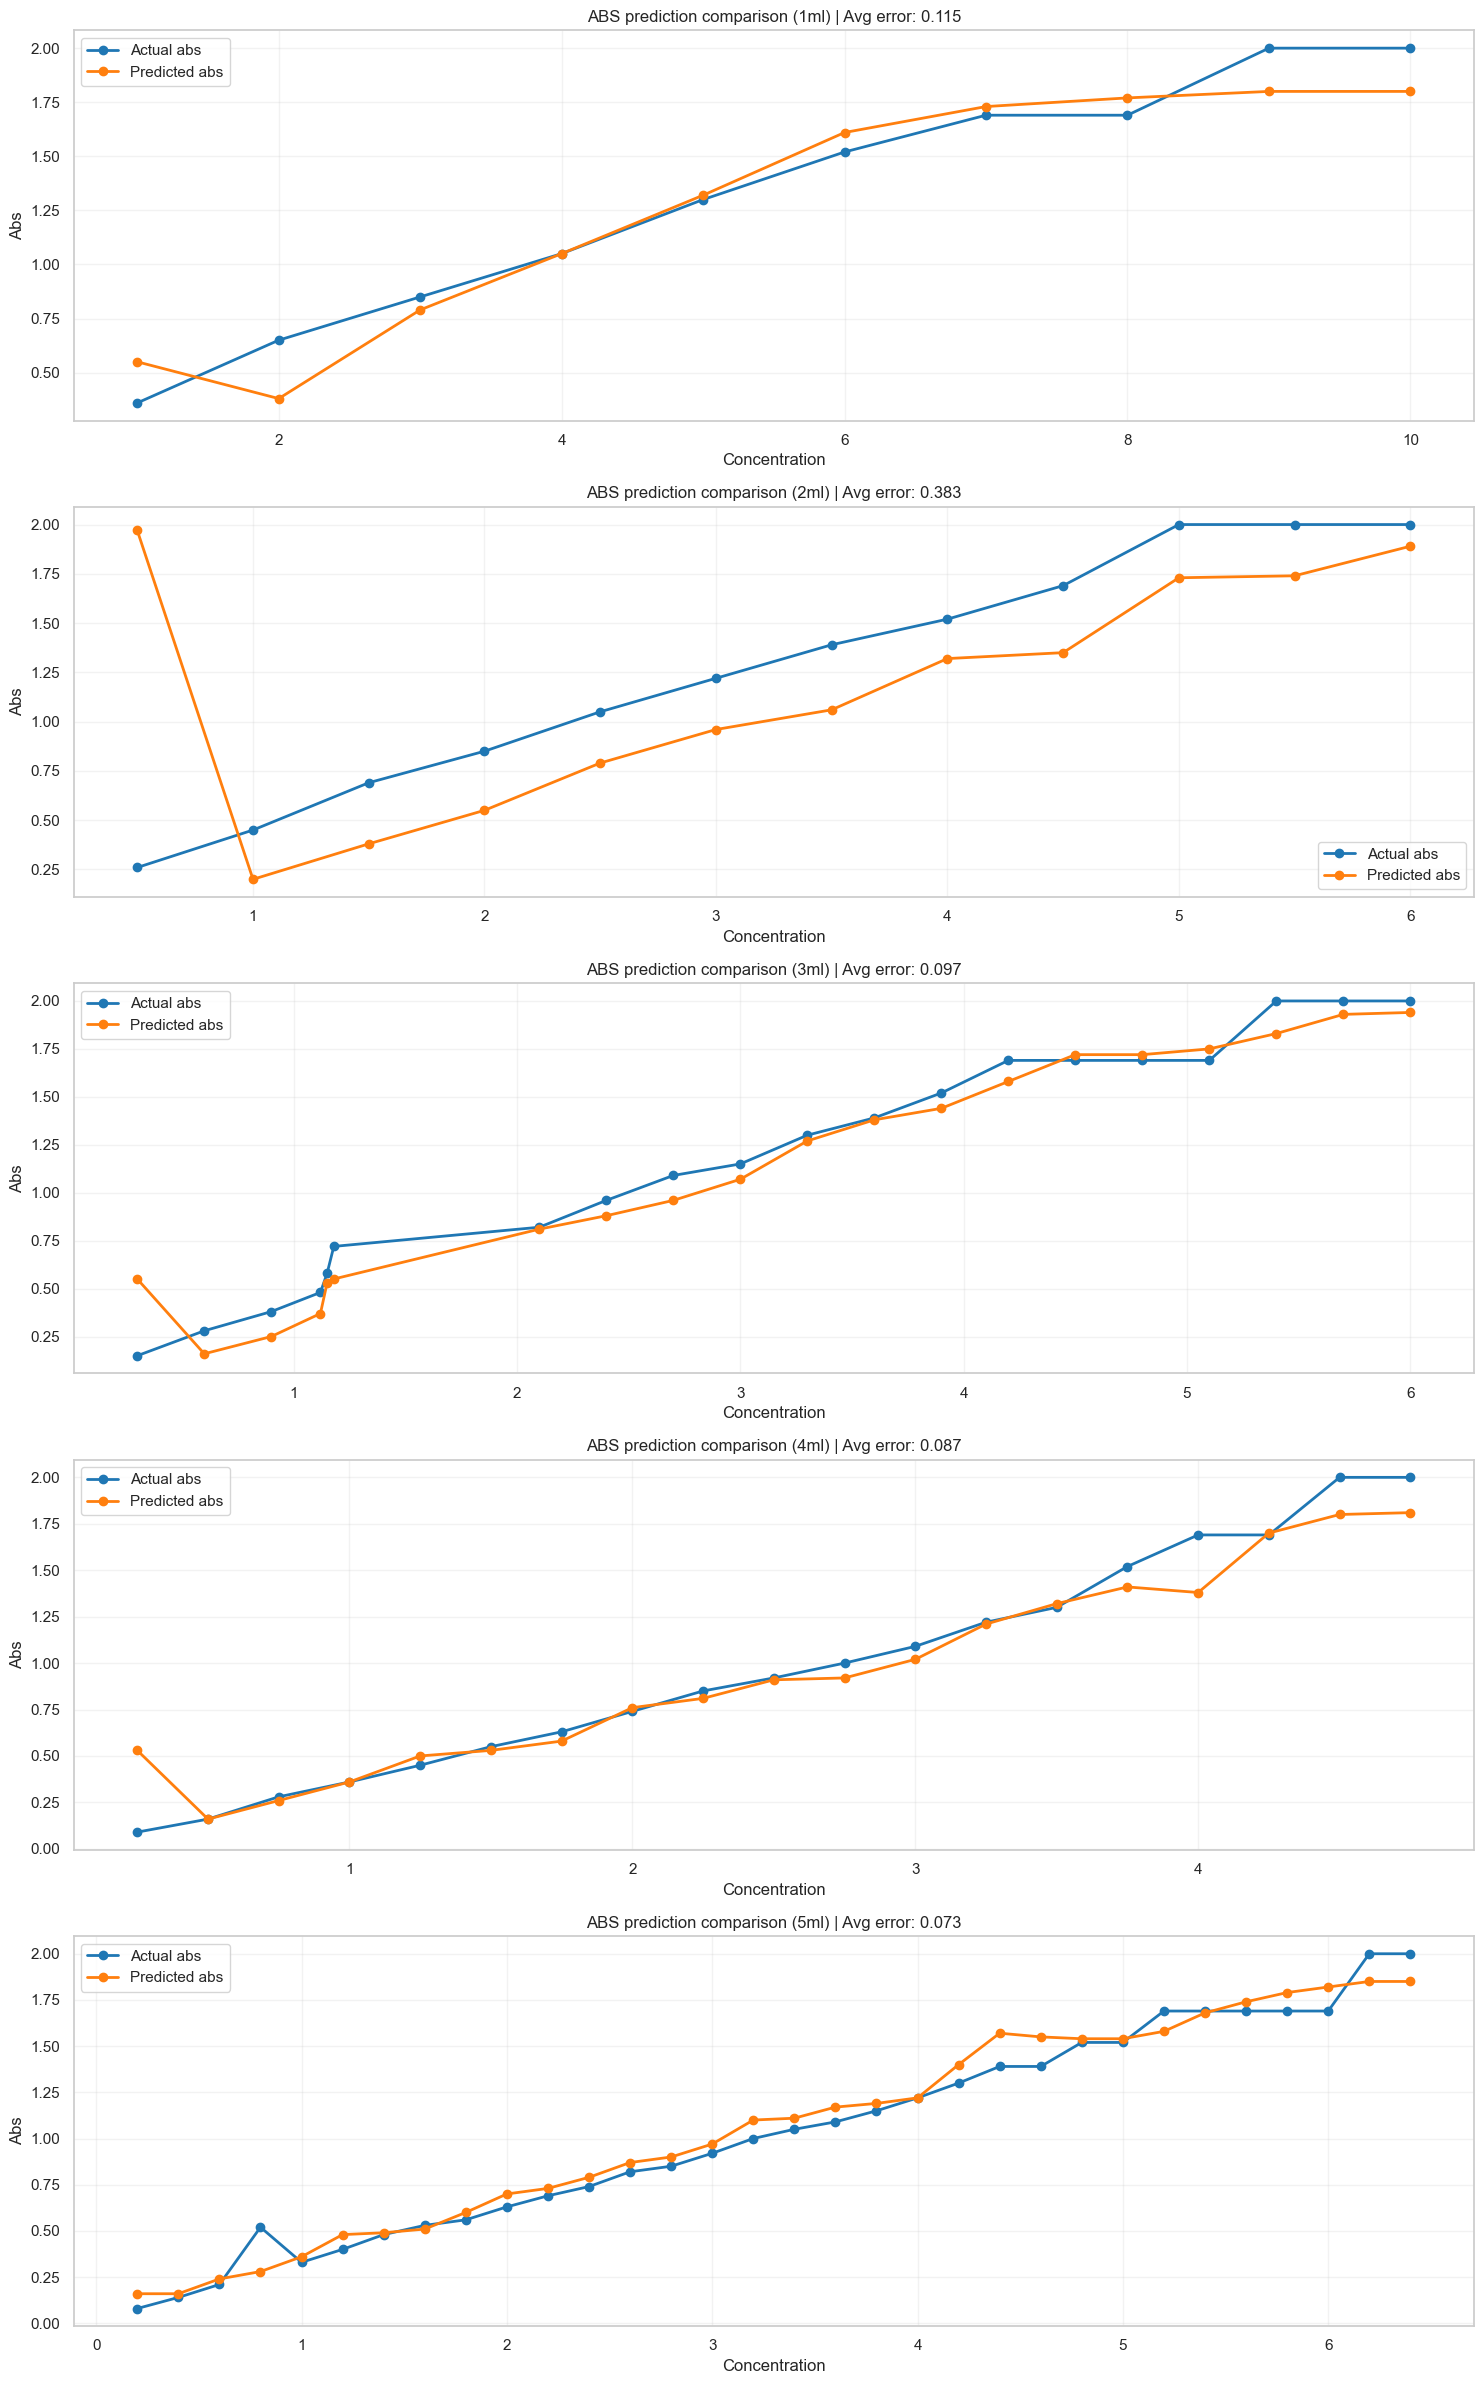

In [7]:
volume_order = ["1ml", "2ml", "3ml", "4ml", "5ml"]
volumes = [v for v in volume_order if v in df["volume"].unique()]

error_summary = (
    df.assign(abs_error=(df["actual_abs"] - df["predicted_abs"]).abs())
      .groupby("volume", as_index=False)["abs_error"]
      .mean()
      .rename(columns={"abs_error": "avg_abs_error"})
)
print("Average absolute error by volume:")
print(error_summary.to_string(index=False))

fig, axes = plt.subplots(5, 1, figsize=(15, 24), sharex=False)
axes = axes.ravel()

actual_color = "#1f77b4"
predicted_color = "#ff7f0e"

for ax, volume in zip(axes, volumes):
    subset = df[df["volume"] == volume].sort_values("conc")
    avg_error = (subset["actual_abs"] - subset["predicted_abs"]).abs().mean()

    ax.plot(subset["conc"], subset["actual_abs"], marker="o", linewidth=2, color=actual_color, label="Actual abs")
    ax.plot(subset["conc"], subset["predicted_abs"], marker="o", linewidth=2, color=predicted_color, label="Predicted abs")

    ax.set_title(f"ABS prediction comparison ({volume}) | Avg error: {avg_error:.3f}")
    ax.set_xlabel("Concentration")
    ax.set_ylabel("Abs")
    ax.legend()
    ax.grid(alpha=0.25)

for ax in axes[len(volumes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Color Mapping Samples

A few representative rows from each volume group with actual and predicted color fields.

In [8]:
import matplotlib.colors as mcolors

# Build a continuous colour mapping using the existing actual_abs -> actual_colour pairs,
# then apply that mapping to predicted_abs to get predicted_colour.
anchors = (
    df[["actual_abs", "actual_colour"]]
      .dropna()
      .drop_duplicates(subset=["actual_abs"], keep="first")
      .sort_values("actual_abs")
)

abs_min = float(anchors["actual_abs"].min())
abs_max = float(anchors["actual_abs"].max())

if abs_max == abs_min:
    def abs_to_hex(_v: float) -> str:
        return str(anchors["actual_colour"].iloc[0])
else:
    positions = ((anchors["actual_abs"] - abs_min) / (abs_max - abs_min)).to_list()
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "actual_abs_colour_map",
        list(zip(positions, anchors["actual_colour"].to_list())),
        N=256,
    )
    norm = mcolors.Normalize(vmin=abs_min, vmax=abs_max)

    def abs_to_hex(v: float) -> str:
        return mcolors.to_hex(cmap(norm(float(v))))

sample_count_per_volume = 3

sampled_frames = []
for volume_name, group in df.assign(predicted_colour=lambda d: d["predicted_abs"].map(abs_to_hex)).groupby("volume"):
    sampled_frames.append(
        group.sample(n=min(sample_count_per_volume, len(group)), random_state=42)
    )

color_samples = (
    pd.concat(sampled_frames, ignore_index=True)
      .sort_values(["volume", "conc"])
      .reset_index(drop=True)
      [["volume", "conc", "actual_abs", "actual_colour", "predicted_abs", "predicted_colour"]]
)

print(f"Showing {sample_count_per_volume} samples per volume (or fewer if a volume has fewer rows).")
display(color_samples)

Showing 3 samples per volume (or fewer if a volume has fewer rows).


,volume,conc,actual_abs,actual_colour,predicted_abs,predicted_colour
0,1ml,2.00,0.65,#634A3E,0.38,#80afaf
1,1ml,6.00,1.52,#1AA0C9,1.61,#0d8bb5
2,1ml,9.00,2.00,#6B6665,1.80,#29728d
3,2ml,0.50,0.26,#9A9185,1.97,#61686b
4,2ml,5.00,2.00,#1594C4,1.73,#10779c
5,2ml,5.50,2.00,#008ABB,1.74,#157699
6,3ml,0.30,0.15,#98A8A2,0.55,#5eb7bf
7,3ml,4.80,1.69,#0087BB,1.72,#0d779d
8,3ml,5.40,2.00,#0089BE,1.83,#337086
9,4ml,0.25,0.09,#BDB8AC,0.53,#2e5a63


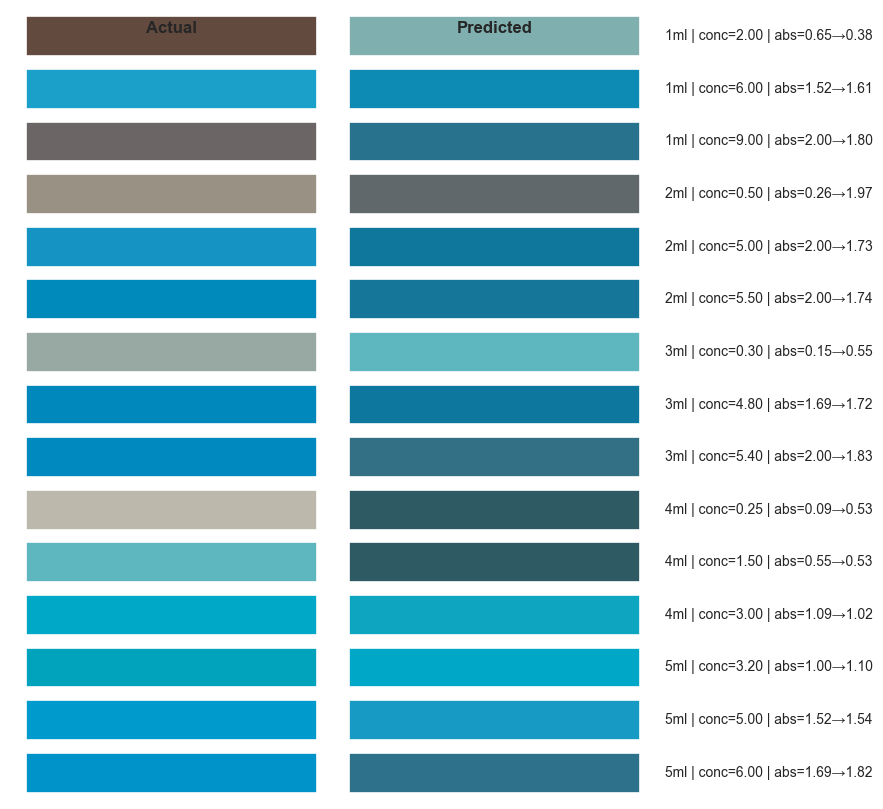

In [10]:
# Visual swatch comparison: Actual vs Predicted colours
import matplotlib.patches as patches

swatch_df = color_samples.copy()

# Sort for a consistent view
swatch_df = swatch_df.sort_values(["volume", "conc"]).reset_index(drop=True)

n = len(swatch_df)
fig_h = max(2.5, 0.55 * n)
fig, ax = plt.subplots(figsize=(9, fig_h))
ax.set_xlim(0, 2)
ax.set_ylim(0, n)
ax.axis("off")

# Column headers
ax.text(0.5, n - 0.2, "Actual", ha="center", va="top", fontsize=12, fontweight="bold")
ax.text(1.5, n - 0.2, "Predicted", ha="center", va="top", fontsize=12, fontweight="bold")

for i, row in swatch_df.iterrows():
    y = n - 1 - i  # top to bottom

    actual_hex = str(row.get("actual_colour", "#000000"))
    pred_hex = str(row.get("predicted_colour", "#000000"))

    # Swatches
    ax.add_patch(patches.Rectangle((0.05, y + 0.12), 0.9, 0.76, facecolor=actual_hex, edgecolor="white", linewidth=1.2))
    ax.add_patch(patches.Rectangle((1.05, y + 0.12), 0.9, 0.76, facecolor=pred_hex, edgecolor="white", linewidth=1.2))

    # Row label
    label = f"{row['volume']} | conc={row['conc']:.2f} | abs={row['actual_abs']:.2f}→{row['predicted_abs']:.2f}"
    ax.text(2.03, y + 0.5, label, ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()
